# 9. Classification - Support Vector Machine (SVM)

**Scratch**: Linear SVM via hinge-loss gradient descent  
**sklearn**: `SVC` with RBF kernel for confirmation

### Theory
Support Vector Machines (SVMs) are large‑margin binary classifiers.  They seek a
linear decision hyperplane

$$f(x)=w^T x + b = 0$$

that separates the two classes with maximum margin.  When the data are scaled so
that the closest points satisfy $|f(x_i)|=1$, the margin width is
$2/\|w\|$.  The label prediction is obtained by the sign of the decision
function:

$$\hat y = \mathrm{sign}(f(x)) = \begin{cases}+1,&f(x)\ge0,\\-1,&f(x)<0.\end{cases}$$

Training minimizes a regularized hinge‑loss objective over a training set
$\\{(x_i,y_i)\\}_{i=1}^n$ with $y_i\in\{\pm1\}$:

$$J(w,b)=\frac12\|w\|^2 + C\sum_{i=1}^n \max\big(0,1-y_i f(x_i)\big)
    =\frac12\|w\|^2 + C\sum_{i=1}^n \ell_i,\qquad\ell_i=\max(0,1-y_i (w^T x_i+b)).$$

The hinge loss $\\ell_i$ penalizes points that lie on the wrong side of the
margin.  In our scratch implementation we absorb $C$ into the learning rate via
$\lambda = 1/C$.

For a single example the subgradient w.r.t.
$w$ is

$$\nabla_w \,\ell_i = \begin{cases}0,&y_i f(x_i)\ge1,\\-y_i x_i,&y_i f(x_i)<1,\end{cases}$$

so that the full gradient becomes

$$\nabla_w J = w + \lambda\begin{cases}0,&y_i f(x_i)\ge1,\\-y_i x_i,&y_i f(x_i)<1.\end{cases}$$

(and $\nabla_b J = -\lambda y_i$ when $y_i f(x_i)<1$, otherwise 0).  The
corresponding update step in (stochastic) gradient descent is
$w\leftarrow w-\eta\nabla_w J$ and
$b\leftarrow b-\eta\nabla_b J$, which is exactly what the scratch class
implements.

In the non‑linear (kernel) setting we would replace $f(x)$ with
$f(x)=\sum_i \alpha_i y_i K(x_i,x)+b$ and optimize dual variables $\alpha_i$,
but here we restrict ourselves to linear SVM and compare an RBF‑kernel version
using `sklearn.svm.SVC` for verification.


## 1. Imports, Setup & Shared Utilities

In [10]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.svm import SVC

BASE_DIR = r"D:\Repo\cryptoflow"

print("os.chdir =" ,os.getcwd())
print("BASE_DIR =", BASE_DIR)
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
print("TRAIN_FILE =", TRAIN_FILE)
print("TEST_FILE =", TEST_FILE)
print("FEATURES_FILE =", FEATURES_FILE )
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Shared utility: compute all 8 classification metrics ──────────────────────
def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}

# ── Shared utility: append results row to CSV ─────────────────────────────────
def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")

# ── Shared utility: plot confusion matrix ─────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")


os.chdir = d:\Repo\cryptoflow\Notebooks
BASE_DIR = D:\Repo\cryptoflow
TRAIN_FILE = D:\Repo\cryptoflow\data\final_training_data_classification_train.csv
TEST_FILE = D:\Repo\cryptoflow\data\final_training_data_classification_test.csv
FEATURES_FILE = D:\Repo\cryptoflow\data\selected_features_classification.json
Utilities loaded.


## 2. Load & Scale Data

In [4]:
print(f"Using BASE_DIR = {BASE_DIR}")
print(f"TRAIN_FILE = {TRAIN_FILE}")
print(f"TEST_FILE = {TEST_FILE}")
print(f"FEATURES_FILE = {FEATURES_FILE}")   
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")

Using BASE_DIR = D:\Repo\cryptoflow
TRAIN_FILE = D:\Repo\cryptoflow\data\final_training_data_classification_train.csv
TEST_FILE = D:\Repo\cryptoflow\data\final_training_data_classification_test.csv
FEATURES_FILE = D:\Repo\cryptoflow\data\selected_features_classification.json
X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']


d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Support Vector Machine - Scratch


  SVM Scratch Linear
  Confusion Matrix : TN=5281  FP=0  FN=5354  TP=0
  Accuracy         : 0.4966
  Precision        : 0.0000
  Sensitivity      : 0.0000
  Specificity(TNR) : 1.0000
  F1-Score         : 0.0000
  ROC-AUC          : 0.5327
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


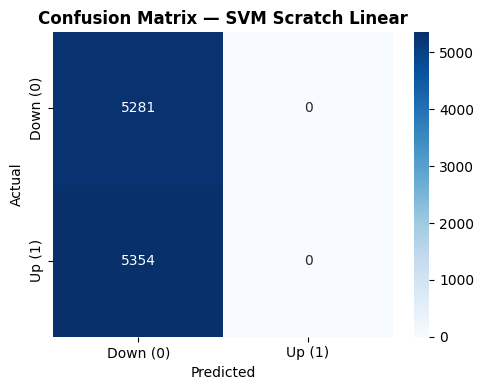

Saved: D:\Repo\cryptoflow\plots\confusion_svm_scratch.png


In [12]:
class SVMScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # convert labels to -1,1
        y_ = np.where(y == 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        return np.sign(self.project(X))

# train scratch SVM
svm_scratch = SVMScratch(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svm_scratch.fit(X_train, y_train)
y_pred_svm = svm_scratch.predict(X_test)
y_pred_svm = np.where(y_pred_svm == -1, 0, 1)

metrics = compute_metrics('SVM Scratch Linear', y_test, y_pred_svm,
                          y_prob=svm_scratch.project(X_test))
save_results(metrics)
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Scratch Linear',
                      os.path.join(PLOTS_DIR, 'confusion_svm_scratch.png'))

## 4. Support Vector Machine - sklearn (RBF Kernel)


  SVM sklearn RBF
  Confusion Matrix : TN=2592  FP=2689  FN=2339  TP=3015
  Accuracy         : 0.5272
  Precision        : 0.5286
  Sensitivity      : 0.5631
  Specificity(TNR) : 0.4908
  F1-Score         : 0.5453
  ROC-AUC          : 0.5429
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


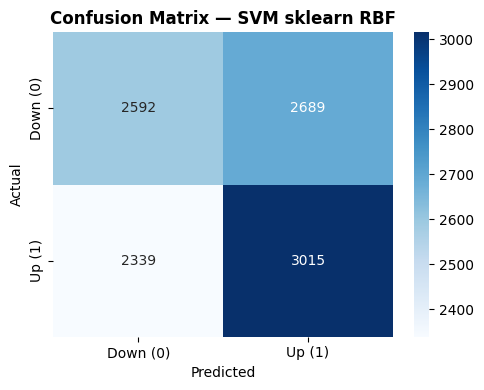

Saved: D:\Repo\cryptoflow\plots\confusion_svm_sklearn.png
SVM training complete.


In [11]:
svm_lib = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_lib.fit(X_train, y_train)
y_pred_lib = svm_lib.predict(X_test)
y_prob_lib = svm_lib.predict_proba(X_test)[:, 1]

metrics_lib = compute_metrics('SVM sklearn RBF', y_test, y_pred_lib, y_prob_lib)
save_results(metrics_lib)
plot_confusion_matrix(y_test, y_pred_lib, 'SVM sklearn RBF',
                      os.path.join(PLOTS_DIR, 'confusion_svm_sklearn.png'))

print("SVM training complete.")